In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(
    "../data/raw/Telco_customer_churn.xlsx"
)

print(df.shape)

df.head()

(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
df.info()

df.describe()

df.isnull().sum()

df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

0

In [3]:

df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [4]:
df = df.drop(columns=[
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
])

In [5]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df.dropna(
    subset=["Total Charges"],
    inplace=True
)

In [6]:
df["Churn Label"] = df["Churn Label"].map({
    "No":0,
    "Yes":1
})

In [7]:
X = df.drop(
    "Churn Label",
    axis=1
)

y = df["Churn Label"]

In [8]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(
    include="object"
).columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        )
    ],
    remainder="passthrough"
)

X_train = preprocessor.fit_transform(
    X_train
)

X_test = preprocessor.transform(
    X_test
)

In [10]:
X_train.shape,
X_test.shape

(1407, 47)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results[name] = accuracy_score(
        y_test,
        y_pred
    )

pd.DataFrame(
    results.items(),
    columns=["Model","Accuracy"]
).sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.801706
3,Random Forest,0.795309
4,AdaBoost,0.794598
5,Gradient Boosting,0.793177
1,KNN,0.737029
2,Decision Tree,0.724947


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params_lr = {
    "C":[0.001,0.01,0.1,1,10,100],
    "penalty":["l2"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(
    X_train,
    y_train
)

print("Best Params :", grid_lr.best_params_)
print("Best Score :", grid_lr.best_score_)

Best Params : {'C': 0.1, 'penalty': 'l2'}
Best Score : 0.8088888888888889


In [13]:
best_lr = LogisticRegression(
    C=0.01,
    penalty="l2",
    max_iter=5000
)

best_lr.fit(
    X_train,
    y_train
)

LogisticRegression(C=0.01, max_iter=5000)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

y_pred_lr = best_lr.predict(X_test)

print(
    accuracy_score(
        y_test,
        y_pred_lr
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_lr
    )
)

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

0.806680881307747
[[922 111]
 [161 213]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [15]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

y_prob_lr = best_lr.predict_proba(
    X_test
)[:,1]

auc_lr = roc_auc_score(
    y_test,
    y_prob_lr
)

print("ROC-AUC :", auc_lr)

ROC-AUC : 0.8440112646308193


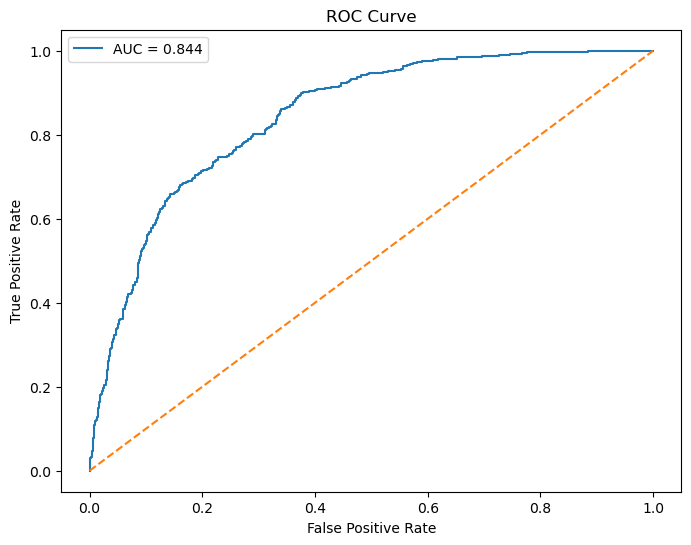

In [16]:
fpr,tpr,_ = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_lr:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_prob = best_lr.predict_proba(X_test)[:,1]

print("Accuracy  :", round(accuracy_score(y_test, y_pred_lr),4))
print("Precision :", round(precision_score(y_test, y_pred_lr),4))
print("Recall    :", round(recall_score(y_test, y_pred_lr),4))
print("F1 Score  :", round(f1_score(y_test, y_pred_lr),4))
print("ROC AUC   :", round(roc_auc_score(y_test, y_prob),4))

Accuracy  : 0.8067
Precision : 0.6574
Recall    : 0.5695
F1 Score  : 0.6103
ROC AUC   : 0.844


In [17]:
import pickle

pickle.dump(
    preprocessor,
    open("../models/preprocessor.pkl","wb")
)

pickle.dump(
    best_lr,
    open("../models/model.pkl","wb")
)

In [18]:
import os

print(
    os.listdir("../models")
)

['model.pkl', 'preprocessor.pkl']


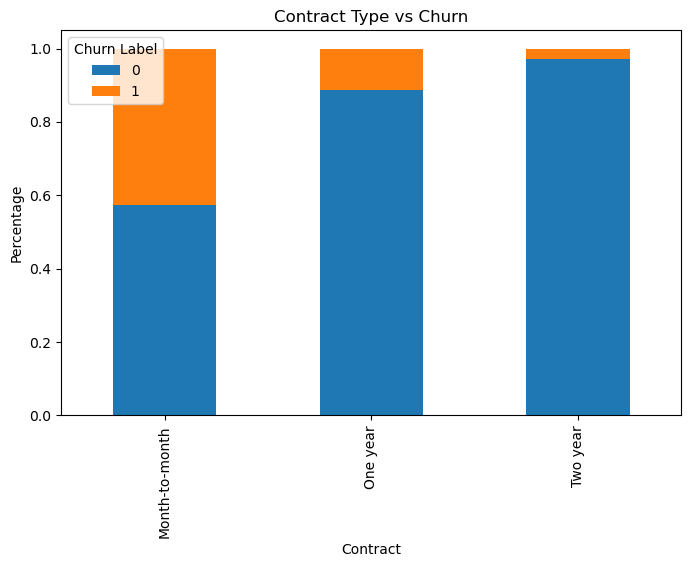

In [19]:
pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.ylabel("Percentage")
plt.show()

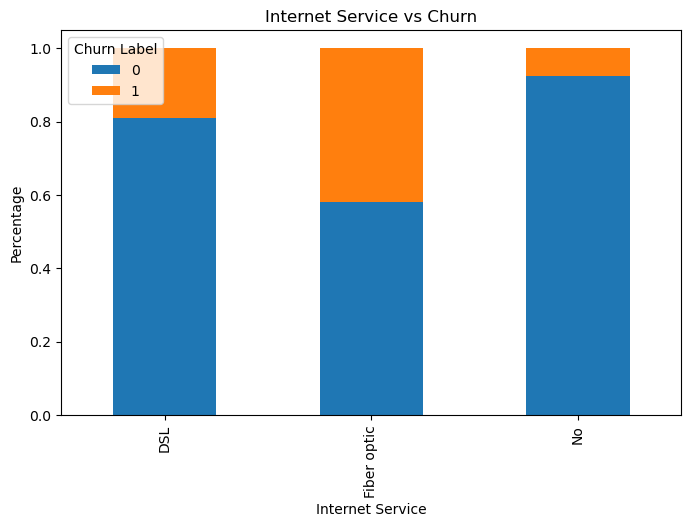

In [20]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Internet Service vs Churn")
plt.ylabel("Percentage")
plt.show()

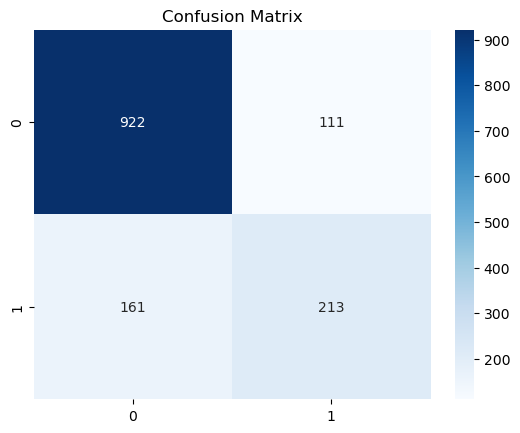

In [21]:
sns.heatmap(
    confusion_matrix(y_test,y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'static/graph/customer_distribution.png'

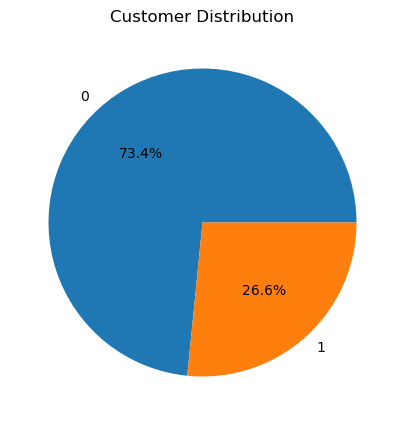

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(8,5))

plt.pie(
    churn_counts.values,
    labels=churn_counts.index,
    autopct="%1.1f%%"
)

plt.title("Customer Distribution")

plt.savefig(
    "static/graph/customer_distribution.png",
    bbox_inches="tight"
)

plt.show()